**Navigation** : [Index](README.md) | [<< Précédent](10_LocalLlama.ipynb) | [Suivant >>](11_Quantization.ipynb)

# 10b. Mécanique d'inférence LLM : construire et mesurer un KV-cache

**Durée estimée** : 75 minutes  
**Niveau** : avancé  
**Prérequis** : attention multi-têtes, PyTorch, notebook 10 (vLLM)

## Objectifs

À la fin de ce notebook, vous saurez :

1. distinguer le **préfill** du **décodage** autorégressif ;
2. expliquer pourquoi le recalcul naïf retraite tout le préfixe ;
3. implémenter un **KV-cache à la main** dans un petit transformeur causal ;
4. vérifier l'identité numérique entre décodages naïf et caché ;
5. mesurer le compromis **latence contre mémoire** ;
6. relier ces mécanismes aux métriques réelles **TTFT** et **ITL** d'un serveur vLLM.

Le notebook emploie un petit modèle aléatoire déterministe : nous étudions la mécanique d'inférence, pas la qualité linguistique. La dernière partie interroge ensuite le vrai endpoint vLLM OpenAI-compatible du dépôt.

## 1. Préfill, décodage et recalcul inutile

Pour un préfixe de longueur $L$, l'attention causale calcule des requêtes $Q$, des clés $K$ et des valeurs $V$. Lorsqu'un nouveau token arrive :

- le **recalcul naïf** reprojette les $L+1$ tokens et recalcule toutes leurs clés et valeurs ;
- le **KV-cache** conserve les anciennes clés/valeurs et ne projette que le nouveau token.

Le cache ne supprime pas l'attention du nouveau token vers le passé : il évite de **reconstruire** ce passé. Son coût mémoire croît linéairement avec la longueur :

$$M_{KV}=2\times n_{layers}\times n_{kv\_heads}\times d_{head}\times L\times bytes(dtype).$$

In [1]:
import json
import math
import os
import statistics
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests
import torch
from dotenv import load_dotenv
from torch import nn

SEED = 42
torch.manual_seed(SEED)
torch.set_num_threads(min(4, os.cpu_count() or 1))
torch.set_grad_enabled(False)

print(f"PyTorch {torch.__version__} | CPU | threads={torch.get_num_threads()} | seed={SEED}")

PyTorch 2.11.0+cpu | CPU | threads=4 | seed=42


### Lecture de l'environnement

Le calcul from scratch est volontairement exécuté sur CPU : il reste reproductible sur une machine d'étudiant. La graine, le nombre de threads et l'absence de gradient bornent la variabilité. Les mesures de production viendront du serveur vLLM, sans prétendre que le CPU local reproduit son GPU.

## 2. Un transformeur causal minimal qui expose K et V

Chaque bloc emploie une normalisation pré-attention, une attention multi-têtes et un MLP. La méthode `forward` accepte un couple `(K_passé, V_passé)` par couche et retourne le cache enrichi.

Le masque causal tient compte de l'offset : en décodage incrémental, la requête du token courant peut voir toutes les clés déjà cachées, mais aucune clé future.

In [2]:
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int) -> None:
        super().__init__()
        if d_model % n_heads != 0:
            raise ValueError("d_model doit être divisible par n_heads")
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model, bias=False)
        self.out = nn.Linear(d_model, d_model, bias=False)

    def _split_heads(self, x: torch.Tensor) -> torch.Tensor:
        batch, length, _ = x.shape
        return x.view(batch, length, self.n_heads, self.head_dim).transpose(1, 2)

    def forward(
        self,
        x: torch.Tensor,
        past_kv: tuple[torch.Tensor, torch.Tensor] | None = None,
    ) -> tuple[torch.Tensor, tuple[torch.Tensor, torch.Tensor]]:
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q, k, v = map(self._split_heads, (q, k, v))
        past_length = 0 if past_kv is None else past_kv[0].shape[2]
        if past_kv is not None:
            k = torch.cat((past_kv[0], k), dim=2)
            v = torch.cat((past_kv[1], v), dim=2)

        query_positions = past_length + torch.arange(q.shape[2], device=x.device)
        key_positions = torch.arange(k.shape[2], device=x.device)
        causal = key_positions[None, :] <= query_positions[:, None]
        scores = q @ k.transpose(-2, -1) / math.sqrt(self.head_dim)
        scores = scores.masked_fill(~causal[None, None, :, :], float("-inf"))
        context = torch.softmax(scores, dim=-1) @ v
        context = context.transpose(1, 2).contiguous().view(x.shape)
        return self.out(context), (k, v)


class TransformerBlock(nn.Module):
    def __init__(self, d_model: int, n_heads: int, expansion: int = 4) -> None:
        super().__init__()
        self.norm_attention = nn.LayerNorm(d_model)
        self.attention = CausalSelfAttention(d_model, n_heads)
        self.norm_mlp = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, expansion * d_model),
            nn.GELU(),
            nn.Linear(expansion * d_model, d_model),
        )

    def forward(self, x, past_kv=None):
        attended, present_kv = self.attention(self.norm_attention(x), past_kv)
        x = x + attended
        x = x + self.mlp(self.norm_mlp(x))
        return x, present_kv


class TinyCausalLM(nn.Module):
    def __init__(
        self,
        vocab_size: int = 256,
        d_model: int = 160,
        n_heads: int = 5,
        n_layers: int = 3,
        max_length: int = 512,
    ) -> None:
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = nn.Embedding(max_length, d_model)
        self.blocks = nn.ModuleList(
            [TransformerBlock(d_model, n_heads) for _ in range(n_layers)]
        )
        self.norm = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.n_layers = n_layers
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads

    def forward(self, token_ids, past_key_values=None):
        past_length = 0 if past_key_values is None else past_key_values[0][0].shape[2]
        positions = past_length + torch.arange(token_ids.shape[1], device=token_ids.device)
        x = self.token_embedding(token_ids) + self.position_embedding(positions)[None, :, :]
        present = []
        for layer_index, block in enumerate(self.blocks):
            past = None if past_key_values is None else past_key_values[layer_index]
            x, layer_kv = block(x, past)
            present.append(layer_kv)
        return self.lm_head(self.norm(x)), tuple(present)


model = TinyCausalLM().eval()
parameter_count = sum(parameter.numel() for parameter in model.parameters())
print(f"Modèle créé : {parameter_count:,} paramètres, {model.n_layers} couches, "
      f"{model.n_heads} têtes, dimension de tête={model.head_dim}")

Modèle créé : 1,090,080 paramètres, 3 couches, 5 têtes, dimension de tête=32


### Lecture des formes internes

Le modèle reste petit, mais son interface reproduit celle d'un LLM de production : un cache par couche, contenant K et V sous la forme `[batch, têtes KV, séquence, dimension de tête]`. Les poids sont identiques dans les deux chemins ; seul le travail réutilisé change.

### Exercice 1 — raisonner sur le masque causal

Modifiez la cellule suivante pour construire, sur papier ou en code, le masque d'un appel incrémental qui reçoit **deux nouveaux tokens** après un cache de longueur 4. Vérifiez quelles clés sont visibles par chacune des deux requêtes.

In [3]:
def exercice_masque_causal() -> None:
    # TODO étudiant : construire et afficher le masque 2 x 6.
    print("Exercice à compléter : masque causal avec offset de cache.")


exercice_masque_causal()

Exercice à compléter : masque causal avec offset de cache.


### Lecture de l'exercice

Le stub s'exécute de bout en bout sans fabriquer de résultat. La propriété à retrouver est différente pour les deux requêtes : la première ne voit pas la seconde, tandis que la seconde voit toutes les positions précédentes, y compris la première requête du même bloc.

## 3. Deux boucles de génération, une seule séquence attendue

La boucle naïve repasse toute la séquence. La boucle cachée effectue un préfill unique, puis appelle le modèle avec un seul token et les K/V précédents. L'argmax rend la comparaison déterministe.

In [4]:
def generate_naive(model, prompt: torch.Tensor, new_tokens: int):
    sequence = prompt.clone()
    step_logits = []
    for _ in range(new_tokens):
        logits, _ = model(sequence)
        current = logits[:, -1, :]
        step_logits.append(current)
        next_token = current.argmax(dim=-1, keepdim=True)
        sequence = torch.cat((sequence, next_token), dim=1)
    return sequence, step_logits


def generate_cached(model, prompt: torch.Tensor, new_tokens: int):
    sequence = prompt.clone()
    logits, cache = model(prompt)
    step_logits = []
    for step in range(new_tokens):
        current = logits[:, -1, :]
        step_logits.append(current)
        next_token = current.argmax(dim=-1, keepdim=True)
        sequence = torch.cat((sequence, next_token), dim=1)
        if step + 1 < new_tokens:
            logits, cache = model(next_token, cache)
    return sequence, step_logits, cache


print("Boucles naïve et cachée définies : recalcul complet vs préfill + décodage incrémental.")

Boucles naïve et cachée définies : recalcul complet vs préfill + décodage incrémental.


### Lecture des deux algorithmes

Le chemin caché n'est pas une approximation : avec les mêmes poids, positions et règle de sélection, il doit fournir les mêmes logits à l'arrondi flottant près. Cette égalité est la preuve de correction avant toute mesure de vitesse.

In [5]:
prompt = torch.randint(0, 256, (1, 48))
naive_sequence, naive_logits = generate_naive(model, prompt, new_tokens=20)
cached_sequence, cached_logits, final_cache = generate_cached(model, prompt, new_tokens=20)

max_logit_error = max(
    (left - right).abs().max().item()
    for left, right in zip(naive_logits, cached_logits)
)
sequences_equal = torch.equal(naive_sequence, cached_sequence)
cache_lengths = [layer_k.shape[2] for layer_k, _ in final_cache]

print(f"Séquences identiques : {sequences_equal}")
print(f"Écart absolu maximal des logits : {max_logit_error:.3e}")
print(f"Longueurs finales des caches par couche : {cache_lengths}")
if not sequences_equal or max_logit_error >= 1e-5:
    raise RuntimeError("Le chemin caché ne reproduit pas le recalcul naïf.")

Séquences identiques : True
Écart absolu maximal des logits : 1.073e-06
Longueurs finales des caches par couche : [67, 67, 67]


### Interprétation de la preuve numérique

La séquence doit être strictement identique et l'écart de logits rester sous la tolérance float32. La longueur finale du cache est `longueur du prompt + tokens déjà injectés dans le cache`; le dernier token sélectionné n'est pas réinjecté quand aucune étape suivante n'est demandée.

## 4. Mesurer le mur de calcul

Un benchmark honnête chauffe les kernels, répète les appels et compare des médianes. Les longueurs testées restent bornées pour un notebook pédagogique. Les temps absolus dépendent de la machine ; le ratio naïf/caché, mesuré dans la même cellule, rend la tendance lisible.

,contexte_tokens,naif_secondes,cache_secondes,naif_tokens_s,cache_tokens_s,acceleration_x
0,32,0.092,0.057,174.734,279.894,1.602
1,64,0.120,0.064,132.788,250.530,1.887
2,128,0.177,0.068,90.529,234.737,2.593
3,256,0.263,0.077,60.951,206.916,3.395


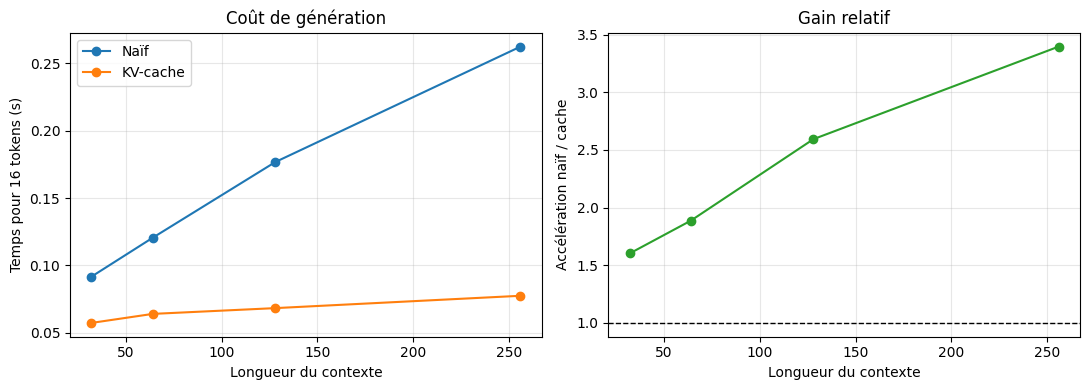

In [6]:
def median_runtime(callable_, repetitions: int = 3) -> float:
    durations = []
    for _ in range(repetitions):
        start = time.perf_counter()
        callable_()
        durations.append(time.perf_counter() - start)
    return statistics.median(durations)


_ = generate_naive(model, torch.randint(0, 256, (1, 32)), 4)
_ = generate_cached(model, torch.randint(0, 256, (1, 32)), 4)

benchmark_rows = []
generated_tokens = 16
for context_length in (32, 64, 128, 256):
    benchmark_prompt = torch.randint(0, 256, (1, context_length))
    naive_seconds = median_runtime(
        lambda p=benchmark_prompt: generate_naive(model, p, generated_tokens)
    )
    cached_seconds = median_runtime(
        lambda p=benchmark_prompt: generate_cached(model, p, generated_tokens)
    )
    benchmark_rows.append(
        {
            "contexte_tokens": context_length,
            "naif_secondes": naive_seconds,
            "cache_secondes": cached_seconds,
            "naif_tokens_s": generated_tokens / naive_seconds,
            "cache_tokens_s": generated_tokens / cached_seconds,
            "acceleration_x": naive_seconds / cached_seconds,
        }
    )

benchmark = pd.DataFrame(benchmark_rows)
display(benchmark.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(benchmark["contexte_tokens"], benchmark["naif_secondes"], "o-", label="Naïf")
axes[0].plot(benchmark["contexte_tokens"], benchmark["cache_secondes"], "o-", label="KV-cache")
axes[0].set(xlabel="Longueur du contexte", ylabel="Temps pour 16 tokens (s)", title="Coût de génération")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[1].plot(benchmark["contexte_tokens"], benchmark["acceleration_x"], "o-", color="tab:green")
axes[1].axhline(1.0, color="black", linewidth=1, linestyle="--")
axes[1].set(xlabel="Longueur du contexte", ylabel="Accélération naïf / cache", title="Gain relatif")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interprétation du benchmark

La courbe naïve doit croître plus vite avec la longueur, car chaque token régénéré retraitera le préfixe. Le chemin caché paie toujours l'attention du nouveau token vers toutes les clés, ainsi que les concaténations de ce prototype ; son coût n'est donc pas constant. Sur les petits contextes, l'overhead Python peut masquer le gain. C'est la tendance aux grandes longueurs — et non un chiffre de temps figé dans la prose — qui matérialise le mur.

## 5. Le cache accélère le calcul en consommant de la mémoire

Mesurons les octets réellement détenus par les tenseurs K/V du toy model, puis confrontons-les à la formule. Nous projetons ensuite la même formule sur deux configurations publiques. Il s'agit d'une **estimation théorique**, pas d'une mesure VRAM de ces grands modèles.

In [7]:
def cache_bytes(cache) -> int:
    return sum(
        tensor.numel() * tensor.element_size()
        for layer_cache in cache
        for tensor in layer_cache
    )


def theoretical_cache_bytes(
    layers: int,
    kv_heads: int,
    head_dim: int,
    sequence_length: int,
    bytes_per_value: int,
) -> int:
    return 2 * layers * kv_heads * head_dim * sequence_length * bytes_per_value


_, toy_cache = model(torch.randint(0, 256, (1, 192)))
measured_toy = cache_bytes(toy_cache)
theoretical_toy = theoretical_cache_bytes(
    model.n_layers, model.n_heads, model.head_dim, 192, 4
)
print(f"Toy mesuré : {measured_toy:,} octets")
print(f"Toy théorique : {theoretical_toy:,} octets")
print(f"Égalité exacte : {measured_toy == theoretical_toy}")
if measured_toy != theoretical_toy:
    raise RuntimeError("La formule mémoire ne correspond pas aux tenseurs mesurés.")

configurations = [
    ("Llama 3.1 8B", 32, 8, 128),
    ("Qwen2.5 7B", 28, 4, 128),
]
projection_rows = []
for name, layers, kv_heads, head_dim in configurations:
    for sequence_length in (2048, 8192, 32768):
        total = theoretical_cache_bytes(layers, kv_heads, head_dim, sequence_length, 2)
        projection_rows.append(
            {
                "configuration": name,
                "contexte": sequence_length,
                "cache_GiB_bf16": total / 1024**3,
            }
        )
projection = pd.DataFrame(projection_rows)
display(projection.round(3))

Toy mesuré : 737,280 octets
Toy théorique : 737,280 octets
Égalité exacte : True


,configuration,contexte,cache_GiB_bf16
0,Llama 3.1 8B,2048,0.250
1,Llama 3.1 8B,8192,1.000
2,Llama 3.1 8B,32768,4.000
3,Qwen2.5 7B,2048,0.109
4,Qwen2.5 7B,8192,0.438
5,Qwen2.5 7B,32768,1.750


### Interprétation de la mémoire

L'égalité exacte sur le toy model valide l'instrument de comptage. Les projections montrent l'effet du **grouped-query attention** : le nombre de têtes KV, et non le nombre total de têtes de requête, entre dans la formule. En production, le cache est en outre multiplié par les séquences simultanées ; vLLM pagine ces blocs pour réduire la fragmentation et mieux partager la mémoire disponible.

### Exercice 2 — généraliser au GQA

Complétez l'estimateur pour comparer une attention multi-têtes classique (`kv_heads = query_heads`) à une GQA (`kv_heads < query_heads`) pour un même `d_model`. Quantifiez le ratio mémoire.

In [8]:
def exercice_memoire_gqa() -> None:
    # TODO étudiant : comparer MHA et GQA à contexte identique.
    print("Exercice à compléter : économie mémoire du grouped-query attention.")


exercice_memoire_gqa()

Exercice à compléter : économie mémoire du grouped-query attention.


### Lecture de l'exercice GQA

Le ratio attendu dépend directement du nombre de têtes KV : passer de 32 têtes KV à 8 divise cette composante mémoire par quatre, sans affirmer que tout le modèle ou toute la VRAM est divisé par quatre.

## 6. Du modèle isolé au serveur vLLM

Les métriques de service mélangent plusieurs mécanismes :

- **TTFT** (*time to first token*) : réseau, attente dans la file, tokenisation et préfill ;
- **ITL** (*inter-token latency*) : cadence des deltas pendant le décodage ;
- **throughput agrégé** : dépend aussi du continuous batching et des requêtes concurrentes.

PagedAttention ne change pas les équations d'attention du toy model : il organise le KV-cache en blocs afin de limiter la fragmentation et de servir efficacement plusieurs séquences.

In [9]:
def load_genai_environment() -> None:
    candidates = [Path.cwd() / "MyIA.AI.Notebooks" / "GenAI" / ".env"]
    candidates.extend(parent / ".env" for parent in (Path.cwd(), *Path.cwd().parents))
    for candidate in candidates:
        if candidate.is_file():
            load_dotenv(candidate, override=False)
            break


def configured_vllm_endpoint() -> dict[str, str]:
    load_genai_environment()
    explicit_names = (
        "VLLM_ENDPOINT_NAME",
        "VLLM_BASE_URL",
        "VLLM_API_KEY",
        "VLLM_MODEL_ID",
    )
    explicit_values = {
        name: os.getenv(name) or ""
        for name in explicit_names
    }
    if explicit_values["VLLM_API_KEY"]:
        return {
            "name": explicit_values["VLLM_ENDPOINT_NAME"] or "vllm-qwen3.6",
            "base_url": (
                explicit_values["VLLM_BASE_URL"]
                or "http://192.168.0.47:5002/v1"
            ),
            "api_key": explicit_values["VLLM_API_KEY"],
            "model": (
                explicit_values["VLLM_MODEL_ID"]
                or "qwen3.6-35b-a3b"
            ),
        }
    if any(explicit_values[name] for name in explicit_names if name != "VLLM_API_KEY"):
        raise RuntimeError(
            "Configuration VLLM_* partielle : VLLM_API_KEY est requis "
            "avec les autres variables explicites."
        )

    for index in range(1, 10):
        suffix = "" if index == 1 else f"_{index}"
        endpoint = {
            "name": os.getenv(f"OPENAI_ENDPOINT_NAME{suffix}") or "",
            "base_url": os.getenv(f"OPENAI_BASE_URL{suffix}") or "",
            "api_key": os.getenv(f"OPENAI_API_KEY{suffix}") or "",
            "model": os.getenv(f"OPENAI_CHAT_MODEL_ID{suffix}") or "",
        }
        endpoint_name = endpoint["name"].lower()
        is_vllm = (
            "vllm" in endpoint_name
            or endpoint_name.startswith("local-mini-")
            or endpoint_name.startswith("local-medium-")
            or endpoint["model"].lower() == "qwen3.6-35b-a3b"
        )
        if is_vllm and all(endpoint.values()):
            return endpoint

    raise RuntimeError(
        "VLLM_API_KEY absent : configurez les variables VLLM_* dans "
        "MyIA.AI.Notebooks/GenAI/.env, ou un slot OPENAI_* local/vLLM, "
        "avant l'exécution complète."
    )


vllm = configured_vllm_endpoint()
headers = {"Authorization": f"Bearer {vllm['api_key']}"}
models_response = requests.get(
    f"{vllm['base_url'].rstrip('/')}/models", headers=headers, timeout=20
)
models_response.raise_for_status()
available_models = [item["id"] for item in models_response.json().get("data", [])]
if vllm["model"] not in available_models:
    raise RuntimeError(f"Modèle configuré absent de /models : {vllm['model']}")
print(f"Endpoint authentifié : {vllm['name']} | modèle={vllm['model']} | /models=OK")

Endpoint authentifié : vllm-qwen3.6 | modèle=qwen3.6-35b-a3b | /models=OK


### Lecture du contrôle vLLM

Cette cellule est volontairement **fail-loud** : la présence d'un service réseau ne suffit pas, il faut une authentification et le modèle attendu dans `/models`. La clé n'est jamais affichée. Une exécution 401 ou un fallback vers un autre fournisseur ne constituerait pas une preuve du vLLM du dépôt.

In [10]:
def stream_chat_metrics(prompt_text: str, max_tokens: int = 32) -> dict:
    payload = {
        "model": vllm["model"],
        "messages": [{"role": "user", "content": prompt_text}],
        "temperature": 0,
        "max_tokens": max_tokens,
        "stream": True,
        "stream_options": {"include_usage": True},
        "chat_template_kwargs": {"enable_thinking": False},
    }
    start = time.perf_counter()
    delta_times = []
    usage = {}
    done_seen = False
    response = requests.post(
        f"{vllm['base_url'].rstrip('/')}/chat/completions",
        headers={**headers, "Content-Type": "application/json"},
        json=payload,
        stream=True,
        timeout=120,
    )
    response.raise_for_status()
    for raw_line in response.iter_lines(decode_unicode=True):
        if not raw_line or not raw_line.startswith("data:"):
            continue
        data = raw_line[5:].strip()
        if data == "[DONE]":
            done_seen = True
            break
        chunk = json.loads(data)
        if chunk.get("usage"):
            usage = chunk["usage"]
        choices = chunk.get("choices") or []
        delta = choices[0].get("delta", {}) if choices else {}
        if delta.get("content"):
            delta_times.append(time.perf_counter())

    if not done_seen:
        raise RuntimeError("Le stream vLLM s'est terminé sans marqueur [DONE].")
    if not delta_times:
        raise RuntimeError("Le stream vLLM n'a produit aucun delta de contenu.")
    prompt_tokens = usage.get("prompt_tokens")
    completion_tokens = usage.get("completion_tokens")
    if prompt_tokens is None or completion_tokens is None:
        raise RuntimeError("Le serveur n'a pas rapporté les compteurs usage.")

    inter_delta = [
        right - left
        for left, right in zip(delta_times, delta_times[1:])
    ]
    itl_effective = (
        (delta_times[-1] - delta_times[0]) / (completion_tokens - 1)
        if completion_tokens > 1
        else 0.0
    )
    return {
        "prompt_tokens": prompt_tokens,
        "completion_tokens": completion_tokens,
        "ttft_s": delta_times[0] - start,
        "itl_effective_s": itl_effective,
        "inter_delta_mediane_s": (
            statistics.median(inter_delta) if inter_delta else 0.0
        ),
        "inter_delta_p95_s": (
            sorted(inter_delta)[
                max(0, math.ceil(0.95 * len(inter_delta)) - 1)
            ]
            if inter_delta
            else 0.0
        ),
        "deltas": len(delta_times),
        "done_seen": done_seen,
    }


warmup = stream_chat_metrics("Réponds uniquement par le mot prêt.", max_tokens=32)
print(
    f"Warm-up streaming réussi : TTFT={warmup['ttft_s']:.3f}s, "
    f"deltas={warmup['deltas']}, [DONE]={warmup['done_seen']}"
)

Warm-up streaming réussi : TTFT=0.259s, deltas=2, [DONE]=True


### Lecture du warm-up

Le warm-up vérifie le chemin SSE complet et évite d'attribuer au premier benchmark un coût ponctuel de connexion ou de compilation. Le TTFT inclut toujours le réseau et la file du serveur : il ne mesure pas le préfill isolé.

,prompt_tokens,ttft_mediane_s,itl_effective_mediane_s,inter_delta_p95_mediane_s,completion_tokens,deltas
0,120,0.2645,0.0104,0.0144,32.0,32.0
1,444,0.3523,0.0121,0.0166,32.0,32.0
2,1308,0.2627,0.0104,0.0140,32.0,32.0


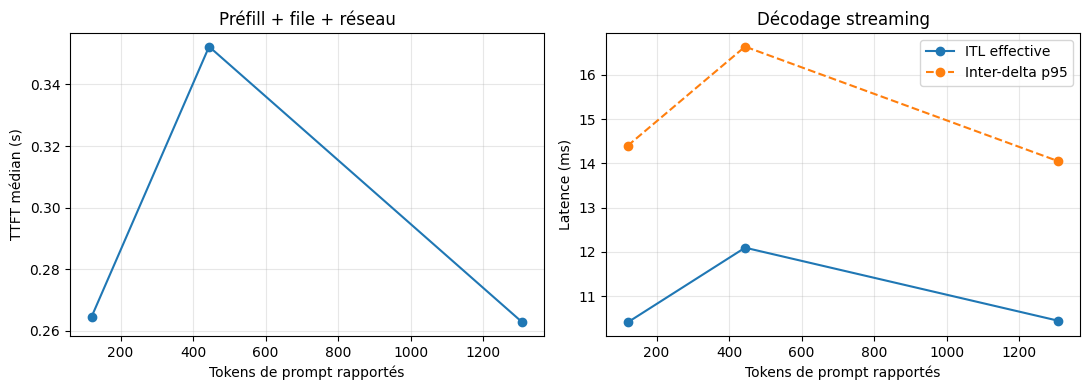

In [11]:
base_sentence = (
    "Explique en une phrase pourquoi un cache de clés et valeurs accélère "
    "le décodage autorégressif sans modifier les logits. "
)
server_rows = []
for repetitions in (4, 16, 48):
    prompt_text = base_sentence * repetitions
    for run in range(3):
        metrics = stream_chat_metrics(prompt_text, max_tokens=32)
        metrics.update({"taille_demandee": repetitions, "répétition": run + 1})
        server_rows.append(metrics)

server_raw = pd.DataFrame(server_rows)
server_summary = (
    server_raw.groupby("prompt_tokens", as_index=False)
    .agg(
        ttft_mediane_s=("ttft_s", "median"),
        itl_effective_mediane_s=("itl_effective_s", "median"),
        inter_delta_p95_mediane_s=("inter_delta_p95_s", "median"),
        completion_tokens=("completion_tokens", "median"),
        deltas=("deltas", "median"),
    )
    .sort_values("prompt_tokens")
)
display(server_summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(
    server_summary["prompt_tokens"],
    server_summary["ttft_mediane_s"],
    "o-",
    color="tab:blue",
)
axes[0].set(
    xlabel="Tokens de prompt rapportés",
    ylabel="TTFT médian (s)",
    title="Préfill + file + réseau",
)
axes[0].grid(alpha=0.3)
axes[1].plot(
    server_summary["prompt_tokens"],
    1000 * server_summary["itl_effective_mediane_s"],
    "o-",
    label="ITL effective",
)
axes[1].plot(
    server_summary["prompt_tokens"],
    1000 * server_summary["inter_delta_p95_mediane_s"],
    "o--",
    label="Inter-delta p95",
)
axes[1].set(
    xlabel="Tokens de prompt rapportés",
    ylabel="Latence (ms)",
    title="Décodage streaming",
)
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interprétation des mesures vLLM

Le mode de raisonnement explicite de Qwen est désactivé pour que le premier delta de contenu corresponde bien au premier token de réponse visible. Le nombre de tokens en abscisse vient du serveur, pas d'une estimation par caractères.

Une hausse du TTFT avec le prompt est cohérente avec un préfill plus long, mais le niveau absolu comprend aussi le réseau, la file et le batching. L'**ITL effective** divise le temps entre premier et dernier delta par le nombre de tokens de complétion rapporté par le serveur : elle reste comparable même lorsque plusieurs tokens sont regroupés dans un delta SSE. Le **p95 inter-delta** mesure quant à lui la gigue observée par le client, pas un p95 token individuel.

Ces courbes relient donc la mécanique from scratch à un système réel sans confondre mesure bout-en-bout, cadence SSE et kernel isolé.

### Exercice 3 — formuler puis tester une hypothèse de service

Ajoutez une quatrième longueur de prompt, prédisez séparément l'effet attendu sur TTFT et ITL, puis répétez la mesure. Documentez aussi l'heure et la charge connue du serveur afin de ne pas surinterpréter une variation de file d'attente.

In [12]:
def exercice_ttft_itl() -> None:
    # TODO étudiant : ajouter une longueur, mesurer, puis confronter l'hypothèse.
    print("Exercice à compléter : nouvelle longueur de prompt et hypothèse TTFT/ITL.")


exercice_ttft_itl()

Exercice à compléter : nouvelle longueur de prompt et hypothèse TTFT/ITL.


### Lecture de l'exercice de service

Le stub ne remplace pas une mesure. Une bonne réponse distingue la direction attendue du TTFT, liée au préfill, de l'ITL, davantage liée au décodage, au batching et à la charge instantanée.

## 7. Synthèse

- Le recalcul naïf reconstruit K et V pour tout le préfixe à chaque token.
- Le KV-cache réutilise ces projections et conserve l'exactitude numérique.
- Le gain de calcul s'achète par une mémoire linéaire en couches, têtes KV et longueur.
- GQA réduit cette mémoire en partageant K/V entre plusieurs têtes de requête.
- En serving, TTFT et ITL sont des métriques bout-en-bout : elles reflètent la mécanique du modèle **et** l'ordonnancement, le batching et le réseau.
- vLLM ajoute PagedAttention et continuous batching pour exploiter le cache efficacement à l'échelle de plusieurs requêtes.

**Pour continuer** : [11_Quantization.ipynb](11_Quantization.ipynb) réduit l'empreinte des poids et montre comment servir des modèles quantifiés avec vLLM.

### Références

- Kwon et al. (2023), *Efficient Memory Management for Large Language Model Serving with PagedAttention*, SOSP'23, arXiv:2309.06180.
- Documentation vLLM, *Optimization and Tuning* et API OpenAI-compatible.
- Meta, configuration Llama 3.1 8B ; Qwen, configuration Qwen2.5 7B.